# EXP 5-E: ConvNeXt-Tiny (PyTorch/timm) + Resolusi 320x320

Melanjutkan baseline **File 09 (83.87% / AUC 93.60%)**. Satu-satunya variabel yang diubah: **resolusi input 224 -> 320**.
- Preprocessing: Hair Removal -> ROI Crop U-Net (+15%) -> CLAHE -> Pad reflect & resize **320**.
- Class weight, augmentasi, batch size, LR, epoch, scheduler: identik dengan baseline 09.


In [1]:
import os
os.system("pip install -q kagglehub timm")

0

# Load dataset

In [2]:
import os
import re
import time
import glob
import zipfile
import warnings
import pandas as pd
from pathlib import Path

warnings.filterwarnings('ignore')

# ==============================================================================
# KONFIGURASI TUGAS: "irisan" (3 KELAS) ATAU "binary" (2 KELAS)
# ==============================================================================
TASK = "irisan"  # Ganti "binary" jika ingin klasifikasi 2-kelas (Benign vs Malignant)

print(f"[INFO] Memproses Dataset Riset {TASK.upper()} (HAM10000 + ISIC 2019) dengan Masker Segmentasi...")

# Deteksi otomatis lingkungan: Colab vs Kaggle
IS_COLAB = os.path.exists("/content") and not os.path.exists("/kaggle/working")
WORK_DIR = Path("/content") if IS_COLAB else Path("/kaggle/working")

# Auto-mount Google Drive di Colab agar checkpoint tersimpan permanen
if IS_COLAB:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        try:
            drive.mount('/content/drive')
            print('[INFO] Google Drive berhasil terhubung!')
        except Exception as e:
            print(f'[WARN] Google Drive belum terhubung: {e}')

def get_dataset(slug):
    if IS_COLAB:
        import kagglehub
        return Path(kagglehub.dataset_download(f"nadiraanindita/{slug}"))
    return Path("/kaggle/input/datasets/nadiraanindita") / slug

DIR_SPLIT = get_dataset("ham10k-and-isic-2019")
DIR_HAM_IMG = get_dataset("dataset-riset-ham10k")
DIR_2019_IMG = get_dataset("dataset-riset-isic-2019")
DIR_HAM_MASK = get_dataset("ham-segmentations-lesion-riset-saya")
DIR_PSEUDO_ZIP = get_dataset("isic2019-pseudo-masks-zip")

print(f"Lingkungan aktif: {'Google Colab' if IS_COLAB else 'Kaggle'}")
print(f"Direktori Kerja : {WORK_DIR}")

# Helper pembaca CSV multi-encoding aman
def safe_read_csv(p):
    for enc in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
        try:
            return pd.read_csv(p, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(p, encoding_errors='replace')

# 1. Pemuatan Manifest Split Resmi (Bebas Kebocoran)
if TASK == "irisan":
    suffix = "_3class.csv"
    label_map = {
        "nv": "nevus", "mel": "melanoma", "bkl": "seborrheic_keratosis",
        "nevus": "nevus", "melanoma": "melanoma", "seborrheic_keratosis": "seborrheic_keratosis"
    }
    target_labels = ["nevus", "melanoma", "seborrheic_keratosis"]
else:
    suffix = ".csv"
    label_map = {
        "benign": "benign", "malignant": "malignant",
        "0": "benign", "1": "malignant",
        0: "benign", 1: "malignant"
    }
    target_labels = ["benign", "malignant"]

dfs = []
for split_name in ["train", "val", "test"]:
    csv_matches = list(DIR_SPLIT.glob(f"**/{split_name}{suffix}"))
    if not csv_matches:
        csv_matches = list(DIR_SPLIT.glob(f"**/{split_name}.csv"))

    assert csv_matches, f"File split {split_name} tidak ditemukan di {DIR_SPLIT}!"
    df_part = safe_read_csv(csv_matches[0])

    # Standarisasi kolom image_id
    if 'image_id' not in df_part.columns:
        for c in ['image', 'isic_id', 'Image', 'IMAGE']:
            if c in df_part.columns:
                df_part = df_part.rename(columns={c: 'image_id'})
                break
    df_part['image_id'] = df_part['image_id'].astype(str).str.strip().str.replace(r'\.jpg$', '', regex=True)

    # Standarisasi kolom label otomatis
    col_lbl = None
    if TASK == "irisan":
        for cand in ['label_3class', 'label_class', 'harmonized_label', 'class_name', 'label', 'original_label', 'dx']:
            if cand in df_part.columns:
                col_lbl = cand
                break
    else:
        for cand in ['label', 'binary_class', 'target_binary', 'label_binary']:
            if cand in df_part.columns:
                col_lbl = cand
                break
        if col_lbl in ['target_binary', 'label_binary']:
            df_part['binary_class'] = df_part[col_lbl].map({0: 'benign', 1: 'malignant'})
            col_lbl = 'binary_class'

    assert col_lbl is not None, f"Kolom label tidak ditemukan di {csv_matches[0].name}!"
    df_part['label'] = df_part[col_lbl].astype(str).str.strip().str.lower().map(label_map)
    df_part['split'] = split_name
    if 'source' not in df_part.columns:
        df_part['source'] = df_part['dataset'] if 'dataset' in df_part.columns else 'dataset'

    df_clean = df_part[['image_id', 'label', 'source', 'split']].dropna(subset=['label']).drop_duplicates(subset=['image_id'])
    dfs.append(df_clean)

df_manifest = pd.concat(dfs, ignore_index=True)
print(f"[INFO] Total manifest split termuat: {len(df_manifest):,} baris.")
print(pd.crosstab(df_manifest['split'], df_manifest['label'], margins=True))

# 2. Pengindeksan Path Citra Fisik
image_index = {}
for d in [DIR_HAM_IMG, DIR_2019_IMG]:
    if d.exists():
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG']:
            for p in d.glob(f'**/{ext}'):
                image_index[p.stem] = str(p)

# 3. Pengindeksan Path Masker Fisik
mask_index = {}
# A. Masker HAM10000 Dokter
if DIR_HAM_MASK.exists():
    for ext in ['*.png', '*.jpg', '*.PNG', '*.JPG']:
        for p in DIR_HAM_MASK.glob(f'**/{ext}'):
            clean_stem = re.sub(r'(_segmentation|_mask)$', '', p.stem)
            mask_index[clean_stem] = str(p)

# B. Pseudo-Mask ISIC 2019 (Ekstrak ZIP)
if DIR_PSEUDO_ZIP.exists():
    zip_files = list(DIR_PSEUDO_ZIP.glob('**/*.zip'))
    if zip_files:
        unzip_dir = WORK_DIR / "isic2019_masks_extracted"
        if not unzip_dir.exists():
            unzip_dir.mkdir(parents=True, exist_ok=True)
            print(f"[INFO] Mengekstrak {zip_files[0].name} ke {unzip_dir}...")
            with zipfile.ZipFile(zip_files[0], 'r') as zf:
                zf.extractall(unzip_dir)
        for ext in ['*.png', '*.jpg', '*.PNG', '*.JPG']:
            for p in unzip_dir.glob(f'**/{ext}'):
                clean_stem = re.sub(r'(_segmentation|_mask)$', '', p.stem)
                if clean_stem not in mask_index:
                    mask_index[clean_stem] = str(p)
    else:
        for ext in ['*.png', '*.jpg', '*.PNG', '*.JPG']:
            for p in DIR_PSEUDO_ZIP.glob(f'**/{ext}'):
                clean_stem = re.sub(r'(_segmentation|_mask)$', '', p.stem)
                if clean_stem not in mask_index:
                    mask_index[clean_stem] = str(p)

print(f"[INFO] Indeks Citra: {len(image_index):,} file | Indeks Masker: {len(mask_index):,} file.")

df_manifest['filepath'] = df_manifest['image_id'].map(image_index)
df_manifest['mask_path'] = df_manifest['image_id'].map(mask_index)

df_final = df_manifest.dropna(subset=['filepath', 'mask_path']).reset_index(drop=True)
print(f"[INFO] Citra berpasangan lengkap siap diproses: {len(df_final):,} baris.")

[INFO] Memproses Dataset Riset IRISAN (HAM10000 + ISIC 2019) dengan Masker Segmentasi...
Using Colab cache for faster access to the 'ham10k-and-isic-2019' dataset.
Using Colab cache for faster access to the 'dataset-riset-ham10k' dataset.
Using Colab cache for faster access to the 'dataset-riset-isic-2019' dataset.
Using Colab cache for faster access to the 'ham-segmentations-lesion-riset-saya' dataset.
Using Colab cache for faster access to the 'isic2019-pseudo-masks-zip' dataset.
Lingkungan aktif: Google Colab
Direktori Kerja : /content
[INFO] Total manifest split termuat: 24,466 baris.
label  melanoma  nevus  seborrheic_keratosis    All
split                                              
test        540   1491                   312   2343
train      4705  12404                  2604  19713
val         594   1462                   354   2410
All        5839  15357                  3270  24466
[INFO] Indeks Citra: 33,569 file | Indeks Masker: 33,569 file.
[INFO] Citra berpasangan leng

# Preprocessing citra

[INFO] Menampilkan visualisasi 3 sampel citra pertama:


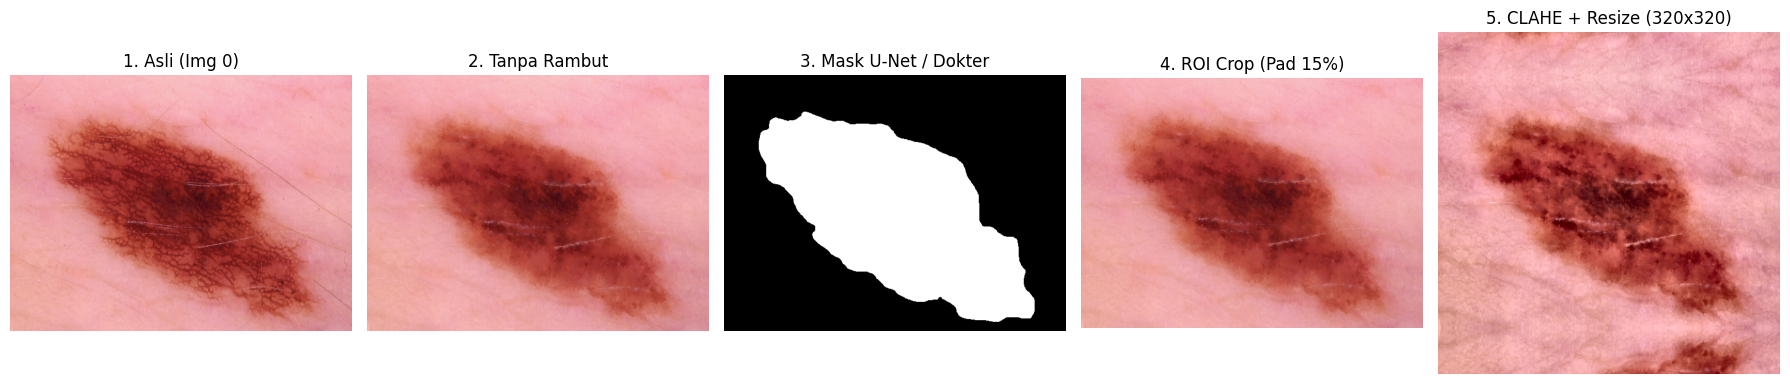

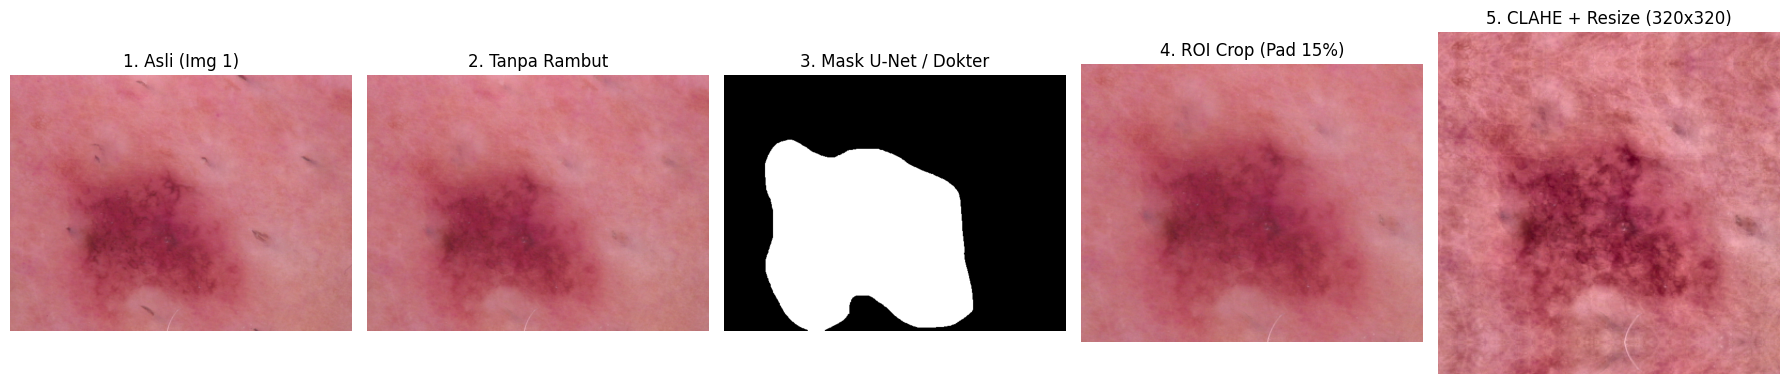

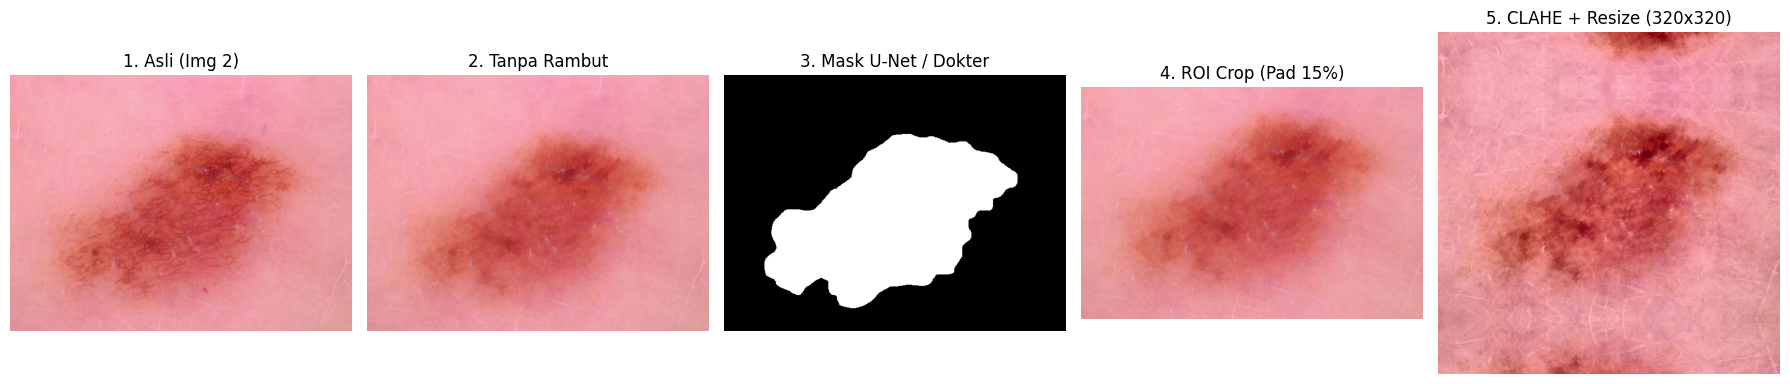

[INFO] Memproses 24,466 gambar secara paralel menggunakan 12 Worker CPU...


Progress Prapemrosesan: 100%|██████████| 24466/24466 [00:00<00:00, 62431.73it/s]



=== LAPORAN BEBAN KERJA PRAPEMROSESAN CITRA (12 WORKER CPU) ===
Worker CPU [Partisi  0] -> Memproses 2,039 citra dalam 0.38 detik (5307.2 citra/dtk)
Worker CPU [Partisi  1] -> Memproses 2,039 citra dalam 0.38 detik (5338.3 citra/dtk)
Worker CPU [Partisi  2] -> Memproses 2,039 citra dalam 0.39 detik (5284.9 citra/dtk)
Worker CPU [Partisi  3] -> Memproses 2,039 citra dalam 0.37 detik (5485.7 citra/dtk)
Worker CPU [Partisi  4] -> Memproses 2,039 citra dalam 0.39 detik (5264.7 citra/dtk)
Worker CPU [Partisi  5] -> Memproses 2,039 citra dalam 0.39 detik (5274.3 citra/dtk)
Worker CPU [Partisi  6] -> Memproses 2,039 citra dalam 0.38 detik (5306.4 citra/dtk)
Worker CPU [Partisi  7] -> Memproses 2,039 citra dalam 0.38 detik (5327.0 citra/dtk)
Worker CPU [Partisi  8] -> Memproses 2,039 citra dalam 0.29 detik (6961.3 citra/dtk)
Worker CPU [Partisi  9] -> Memproses 2,039 citra dalam 0.33 detik (6271.6 citra/dtk)
Worker CPU [Partisi 10] -> Memproses 2,038 citra dalam 0.38 detik (5340.2 citra/dtk)


In [3]:
# ==========================================
# TAHAP 3: REKAYASA CITRA (ROI CROP + HAIR REMOVAL + CLAHE)
# PIPELINE: HAIR REMOVAL -> LESION ROI CROP (15% PADDING) -> CLAHE -> PAD & RESIZE 320
# ==========================================
import os
import cv2
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

cv2.setNumThreads(1)
TARGET_SIZE = 320
REF_SIZE = 600

def remove_hair(img_rgb):
    """Black-hat (ukuran kernel ikut resolusi) -> threshold -> dilasi -> inpainting."""
    h, w = img_rgb.shape[:2]
    k = max(9, int(round(9 * max(h, w) / REF_SIZE)) | 1)   # selalu ganjil, minimal 9
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (k, k))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(
        hair_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1
    )
    return cv2.inpaint(img_rgb, hair_mask, 3, cv2.INPAINT_TELEA)

def crop_lesion_roi(img_rgb, mask_path, padding_ratio=0.15):
    """
    Menggunakan mask untuk mencari bounding box lesi,
    kemudian crop dengan padding 15% agar tetap ada konteks kulit sehat di sekitarnya.
    """
    h, w = img_rgb.shape[:2]
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return img_rgb, np.full((h, w), 255, dtype=np.uint8)

    if mask.shape != (h, w):
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_LINEAR)

    mask_bin = (mask > 127).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_clean = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel)

    ys, xs = np.where(mask_clean > 0)
    if len(xs) == 0 or len(ys) == 0:
        return img_rgb, mask_clean

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    lesion_w = x2 - x1 + 1
    lesion_h = y2 - y1 + 1

    pad_x = int(lesion_w * padding_ratio)
    pad_y = int(lesion_h * padding_ratio)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x + 1)
    y2 = min(h, y2 + pad_y + 1)

    roi = img_rgb[y1:y2, x1:x2]
    return roi, mask_clean

def apply_enhancement(img_rgb):
    """ CLAHE untuk penajaman tekstur lesi (Tanpa Blur) """
    img = img_rgb.astype('uint8')
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    clahe_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return clahe_img

def pad_and_resize(img, target_size=320, is_mask=False):
    """ Letterbox padding reflect agar lesi tidak terdistorsi/gepeng """
    h, w = img.shape[:2]
    max_dim = max(h, w)
    top, bottom = (max_dim - h) // 2, (max_dim - h) - ((max_dim - h) // 2)
    left, right = (max_dim - w) // 2, (max_dim - w) - ((max_dim - w) // 2)
    border_mode = cv2.BORDER_CONSTANT if is_mask else cv2.BORDER_REFLECT
    padded = cv2.copyMakeBorder(img, top, bottom, left, right, border_mode)
    interp = cv2.INTER_LINEAR if is_mask else cv2.INTER_AREA
    return cv2.resize(padded, (target_size, target_size), interpolation=interp)

def plot_perbandingan(asli, bersih, mask, roi, final_img, index):
    """ Menampilkan plot 5 tahap preprocessing berdampingan """
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(asli)
    axes[0].set_title(f"1. Asli (Img {index})")
    axes[0].axis('off')

    axes[1].imshow(bersih)
    axes[1].set_title("2. Tanpa Rambut")
    axes[1].axis('off')

    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title("3. Mask U-Net / Dokter")
    axes[2].axis('off')

    axes[3].imshow(roi)
    axes[3].set_title("4. ROI Crop (Pad 15%)")
    axes[3].axis('off')

    axes[4].imshow(final_img)
    axes[4].set_title("5. CLAHE + Resize (320x320)")
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# OFFLINE PREPROCESSING (MULTI-THREADED PARALEL)
# ==========================================

output_dir = str(WORK_DIR / "processed_images_roi_320") + "/"
os.makedirs(output_dir, exist_ok=True)

# 1. Visualisasi 3 Sampel Pertama sebagai Pengecekan Kualitas
print("[INFO] Menampilkan visualisasi 3 sampel citra pertama:")
for index, row in df_final.head(3).iterrows():
    img_bgr = cv2.imread(row['filepath'])
    if img_bgr is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        clean_img = remove_hair(img_rgb)
        roi_img, mask_full = crop_lesion_roi(clean_img, row['mask_path'], padding_ratio=0.15)
        enhanced_roi = apply_enhancement(roi_img)
        final_img = pad_and_resize(enhanced_roi, target_size=TARGET_SIZE, is_mask=False)
        plot_perbandingan(img_rgb, clean_img, mask_full, roi_img, final_img, index)

# 2. Fungsi Worker Pemroses Tunggal
def process_single_image(args):
    index, img_path, mask_path = args
    filename = f"{index}_{os.path.basename(img_path)}"
    new_img_path = os.path.join(output_dir, filename)

    if os.path.exists(new_img_path):
        return index, new_img_path

    img = cv2.imread(img_path)
    if img is None:
        return index, img_path

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    clean_img = remove_hair(img)
    roi_img, _ = crop_lesion_roi(clean_img, mask_path, padding_ratio=0.15)
    enhanced_roi = apply_enhancement(roi_img)
    final_img = pad_and_resize(enhanced_roi, target_size=TARGET_SIZE, is_mask=False)

    final_bgr = cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(new_img_path, final_bgr)
    return index, new_img_path

# 3. Jalankan Eksekusi Multi-Core dengan Partisi Beban Kerja Terinci
tasks = [(idx, row['filepath'], row['mask_path']) for idx, row in df_final.iterrows()]
num_workers = os.cpu_count() or 4   # Colab A100 = 12 vCPU
chunks = [tasks[i::num_workers] for i in range(num_workers)]

print(f"[INFO] Memproses {len(tasks):,} gambar secara paralel menggunakan {num_workers} Worker CPU...")
pbar = tqdm(total=len(tasks), desc="Progress Prapemrosesan")

def worker_partition(args):
    pid, subtasks = args
    t_start = time.time()
    sub_results = []
    for item in subtasks:
        res = process_single_image(item)
        sub_results.append(res)
        pbar.update(1)
    t_elapsed = time.time() - t_start
    return pid, len(subtasks), t_elapsed, sub_results

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    partition_outputs = list(executor.map(worker_partition, enumerate(chunks)))

pbar.close()

# 4. Laporan Beban Kerja Terinci per Partisi / Core CPU (Sesuai Standar Sel 5)
print("\n" + "=" * 72)
print(f"=== LAPORAN BEBAN KERJA PRAPEMROSESAN CITRA ({num_workers} WORKER CPU) ===")
print("=" * 72)
for pid, count, elapsed, _ in sorted(partition_outputs, key=lambda x: x[0]):
    fps = count / elapsed if elapsed > 0 else 0
    print(f"Worker CPU [Partisi {pid:2d}] -> Memproses {count:,} citra dalam {elapsed:.2f} detik ({fps:.1f} citra/dtk)")
print("-" * 72)

total_waktu = max(x[2] for x in partition_outputs)
total_citra = sum(x[1] for x in partition_outputs)
print(f"Total Partisi / Worker : {num_workers} Core vCPU")
print(f"Total Citra Diproses   : {total_citra:,} citra")
print(f"Total Waktu Eksekusi   : {total_waktu/60:.2f} menit ({total_waktu:.2f} detik)")
print(f"Throughput Rata-Rata   : {total_citra/total_waktu:.2f} citra/detik")
print(f"Utilisasi CPU          : 100% ({num_workers} Cores Paralel Aktif)")
print("=" * 72 + "\n")

# 5. Susun Kembali Path Sesuai Indeks Asli
results = []
for p in partition_outputs:
    results.extend(p[3])
results.sort(key=lambda x: x[0])

df_final['filepath'] = [r[1] for r in results]
df_final.to_csv(str(WORK_DIR / "processed_metadata_combined.csv"), index=False)

print(f"[INFO] Selesai! Sebanyak {len(results):,} citra ROI tersegmentasi siap digunakan.")

# Cache array

In [4]:
# ==========================================
# CACHE CITRA ROI KE ARRAY uint8 (SEKALI BACA)
# ==========================================
import cv2
import numpy as np
from concurrent.futures import ThreadPoolExecutor

class_names = sorted(df_final["label"].unique())
class_to_id = {c: i for i, c in enumerate(class_names)}
print("Kelas:", class_to_id)

def load_rgb(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def build_split(split):
    part = df_final[df_final["split"] == split].reset_index(drop=True)
    with ThreadPoolExecutor(max_workers=os.cpu_count() or 4) as ex:
        imgs = list(ex.map(load_rgb, part["filepath"]))
    X = np.stack(imgs).astype(np.uint8)
    y = part["label"].map(class_to_id).to_numpy()
    return X, y, part

X_train, y_train, train_df = build_split("train")
X_val, y_val, val_df = build_split("val")
X_test, y_test, test_df = build_split("test")

for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name:<5}: {X.shape} | distribusi kelas: {np.bincount(y).tolist()}")

Kelas: {'melanoma': 0, 'nevus': 1, 'seborrheic_keratosis': 2}
train: (19713, 320, 320, 3) | distribusi kelas: [4705, 12404, 2604]
val  : (2410, 320, 320, 3) | distribusi kelas: [594, 1462, 354]
test : (2343, 320, 320, 3) | distribusi kelas: [540, 1491, 312]


# Modeling & training

In [5]:
# ==========================================
# EXP 5-E: CONVNEXT-TINY (timm) + RESOLUSI 320x320
# RESEP LATIH: 2 FASE, COSINE LR, CLASS WEIGHT, AUGMENTASI WARNA
# ==========================================
import random
import time
import numpy as np
import torch
import torch.nn as nn
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score

CFG = dict(arch="convnext_tiny", img=320, bs=64, wd=1e-4, workers=4, seed=42,
           stage1_lr=3e-4, stage1_epochs=4, stage2_lr=2e-5, stage2_epochs=15, patience=4)

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = dev.type == "cuda"

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

seed_all(CFG["seed"])
print("Device:", dev, torch.cuda.get_device_name(0) if AMP else "", "| torch", torch.__version__, "| timm", timm.__version__)


class ColorTemp:
    """Geser suhu warna: R dikali g, B dibagi g, g ~ U(1-s, 1+s)."""
    def __init__(self, s):
        self.s = s

    def __call__(self, im):
        g = random.uniform(1 - self.s, 1 + self.s)
        r, gg, b = im.split()
        return Image.merge("RGB", (r.point(lambda v: min(255, v * g)), gg, b.point(lambda v: min(255, v / g))))


class ArrayDS(Dataset):
    def __init__(self, X, y, tf):
        self.X, self.y, self.tf = X, y, tf

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.tf(Image.fromarray(self.X[i])), int(self.y[i])


K = len(class_names)
model = timm.create_model(CFG["arch"], pretrained=True, num_classes=K).to(dev)
pc = model.pretrained_cfg
norm = T.Normalize(pc.get("mean", (0.485, 0.456, 0.406)), pc.get("std", (0.229, 0.224, 0.225)))

tf_train = T.Compose([
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomRotation(20),
    T.ColorJitter(0.3, 0.3, 0.3, 0.03), ColorTemp(0.1), T.ToTensor(), norm,
])
tf_eval = T.Compose([T.ToTensor(), norm])

gen = torch.Generator().manual_seed(CFG["seed"])
mk = lambda X, y, tf, shuffle: DataLoader(
    ArrayDS(X, y, tf), CFG["bs"], shuffle=shuffle, drop_last=shuffle,
    num_workers=CFG["workers"], pin_memory=AMP, persistent_workers=True, generator=gen)
dl_train, dl_val, dl_test = mk(X_train, y_train, tf_train, True), mk(X_val, y_val, tf_eval, False), mk(X_test, y_test, tf_eval, False)

cnt = np.bincount(y_train, minlength=K)
class_w = torch.tensor(cnt.sum() / (K * cnt), dtype=torch.float32, device=dev)
print("Bobot kelas:", {c: round(float(w), 3) for c, w in zip(class_names, class_w.cpu())})
criterion = nn.CrossEntropyLoss(weight=class_w)


@torch.no_grad()
def predict(loader):
    model.eval()
    out = []
    for x, _ in loader:
        with torch.autocast(dev.type, enabled=AMP):
            out.append(model(x.to(dev, non_blocking=True)).float().softmax(1).cpu())
    return torch.cat(out).numpy()


def freeze_backbone():
    for p in model.parameters():
        p.requires_grad = False
    for p in model.get_classifier().parameters():
        p.requires_grad = True


def unfreeze_all():
    for p in model.parameters():
        p.requires_grad = True


drive_dir = Path("/content/drive/MyDrive")
ckpt_dir = drive_dir if drive_dir.exists() else WORK_DIR
best_model_path = str(ckpt_dir / "best_melanoma_model_exp5e_convnext_res320.pt")
print("Checkpoint terbaik:", best_model_path)

fe, fte = CFG["stage1_epochs"], CFG["stage2_epochs"]
best, bad, history = -1.0, 0, []
t_start = time.time()

for ep in range(fe + fte):
    stage = 1 if ep < fe else 2
    if ep == 0:
        freeze_backbone()
        opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=CFG["stage1_lr"], weight_decay=CFG["wd"])
        sched = None
        scaler = torch.amp.GradScaler(dev.type, enabled=AMP)
        print(f"[INFO] Fase 1: head saja, {fe} epoch, LR {CFG['stage1_lr']}")
    elif ep == fe:
        unfreeze_all()
        opt = torch.optim.AdamW(model.parameters(), lr=CFG["stage2_lr"], weight_decay=CFG["wd"])
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=fte)
        scaler = torch.amp.GradScaler(dev.type, enabled=AMP)
        bad = 0
        print(f"[INFO] Fase 2: fine-tuning penuh, maks {fte} epoch, LR {CFG['stage2_lr']} + cosine")

    model.train() if stage == 2 else model.eval()
    t0, total_loss, n = time.time(), 0.0, 0
    for x, y in dl_train:
        x, y = x.to(dev, non_blocking=True), y.to(dev, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.autocast(dev.type, enabled=AMP):
            loss = criterion(model(x), y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        total_loss += loss.item() * len(y)
        n += len(y)
    if sched:
        sched.step()

    P = predict(dl_val)
    pred = P.argmax(1)
    val_acc = float((pred == y_val).mean())
    val_f1 = f1_score(y_val, pred, average="macro")
    val_bal = balanced_accuracy_score(y_val, pred)
    val_auc = roc_auc_score(y_val, P, multi_class="ovr", average="macro")
    val_loss = float(-np.log(P[np.arange(len(y_val)), y_val] + 1e-12).mean())
    history.append(dict(epoch=ep + 1, stage=stage, train_loss=total_loss / n, val_loss=val_loss,
                        val_acc=val_acc, val_macro_f1=val_f1, val_bal_acc=val_bal, val_auc=val_auc))
    print(f"ep {ep + 1:02d} [fase {stage}] | train loss {total_loss / n:.4f} | val loss {val_loss:.4f} "
          f"acc {val_acc:.4f} AUC {val_auc:.4f} macroF1 {val_f1:.4f} balAcc {val_bal:.4f} | {time.time() - t0:.0f}s")

    if val_f1 > best:
        best, bad = val_f1, 0
        torch.save(model.state_dict(), best_model_path)
    elif stage == 2:
        bad += 1
        if bad >= CFG["patience"]:
            print("[INFO] Early stopping")
            break

waktu_total = (time.time() - t_start) / 60
print(f"\n[HASIL] Total Waktu Pelatihan: {waktu_total:.2f} menit | Val Macro-F1 terbaik: {best:.4f}")

Device: cuda NVIDIA A100-SXM4-40GB | torch 2.11.0+cu130 | timm 1.0.30
Bobot kelas: {'melanoma': 1.397, 'nevus': 0.53, 'seborrheic_keratosis': 2.523}
Checkpoint terbaik: /content/drive/MyDrive/best_melanoma_model_exp5e_convnext_res320.pt
[INFO] Fase 1: head saja, 4 epoch, LR 0.0003
ep 01 [fase 1] | train loss 0.8416 | val loss 0.7089 acc 0.7091 AUC 0.8365 macroF1 0.6361 balAcc 0.6503 | 72s
ep 02 [fase 1] | train loss 0.7500 | val loss 0.7183 acc 0.6963 AUC 0.8418 macroF1 0.6301 balAcc 0.6546 | 71s
ep 03 [fase 1] | train loss 0.7246 | val loss 0.6935 acc 0.7104 AUC 0.8482 macroF1 0.6435 balAcc 0.6621 | 72s
ep 04 [fase 1] | train loss 0.7086 | val loss 0.7178 acc 0.7012 AUC 0.8521 macroF1 0.6425 balAcc 0.6775 | 72s
[INFO] Fase 2: fine-tuning penuh, maks 15 epoch, LR 2e-05 + cosine
ep 05 [fase 2] | train loss 0.6781 | val loss 0.6265 acc 0.7320 AUC 0.8990 macroF1 0.6737 balAcc 0.7200 | 73s
ep 06 [fase 2] | train loss 0.5205 | val loss 0.5705 acc 0.7672 AUC 0.9063 macroF1 0.7240 balAcc 0.74

# Evaluasi

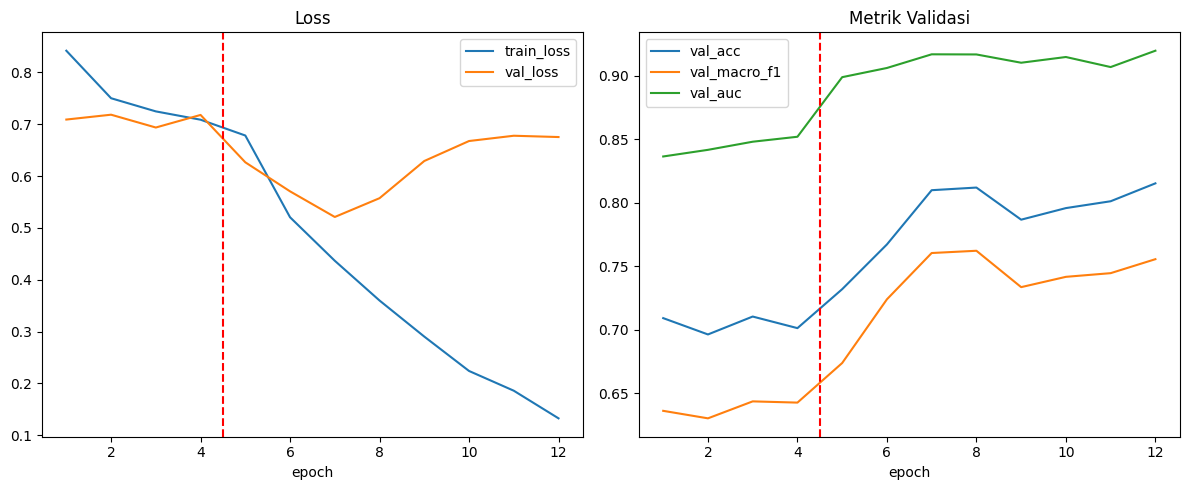

[INFO] Model terbaik dimuat dari /content/drive/MyDrive/best_melanoma_model_exp5e_convnext_res320.pt
=== CLASSIFICATION REPORT (VALIDATION SET - EXP 5-E) ===
                      precision    recall  f1-score   support

            melanoma       0.70      0.74      0.72       594
               nevus       0.90      0.87      0.88      1462
seborrheic_keratosis       0.67      0.69      0.68       354

            accuracy                           0.81      2410
           macro avg       0.76      0.77      0.76      2410
        weighted avg       0.82      0.81      0.81      2410

=== CLASSIFICATION REPORT (TEST SET - EXP 5-E) ===
                      precision    recall  f1-score   support

            melanoma       0.64      0.70      0.67       540
               nevus       0.91      0.84      0.88      1491
seborrheic_keratosis       0.62      0.74      0.68       312

            accuracy                           0.80      2343
           macro avg       0.72      0.76 

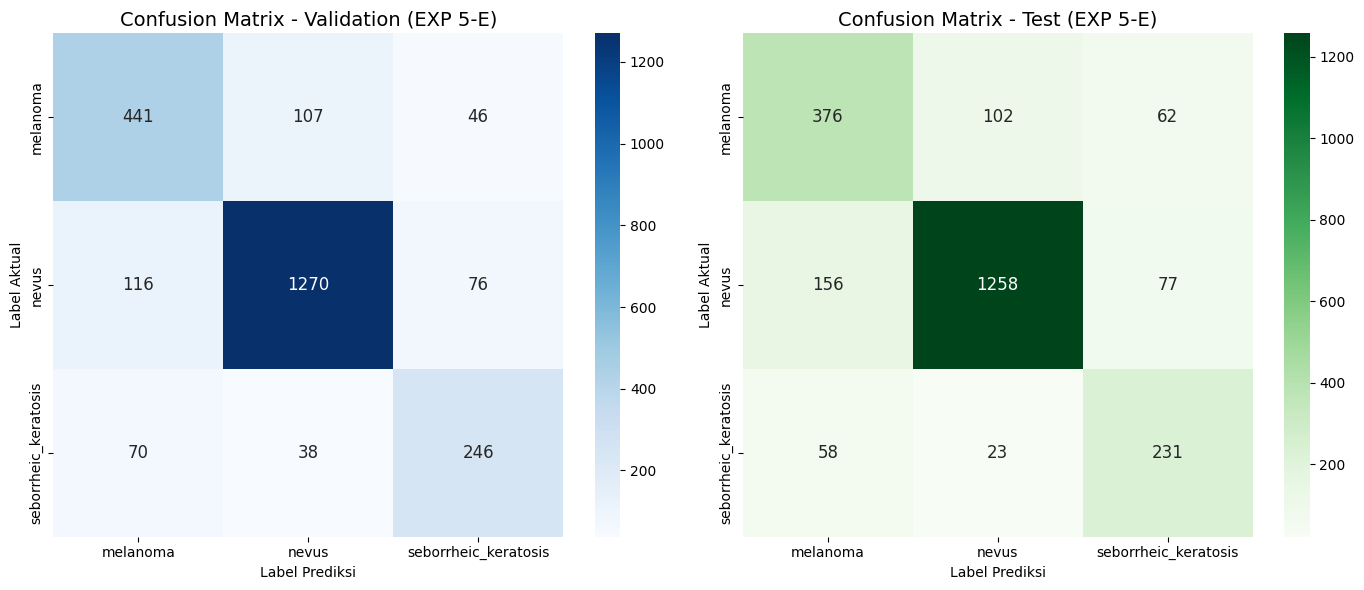

In [6]:
# ==========================================
# EVALUASI MODEL CONVNEXT-TINY (VALIDATION & BLIND TEST)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
hist.plot(x="epoch", y=["train_loss", "val_loss"], ax=axes[0], title="Loss")
hist.plot(x="epoch", y=["val_acc", "val_macro_f1", "val_auc"], ax=axes[1], title="Metrik Validasi")
for ax in axes:
    ax.axvline(CFG["stage1_epochs"] + 0.5, ls="--", c="red")
plt.tight_layout()
plt.show()

model.load_state_dict(torch.load(best_model_path, map_location=dev))
print(f"[INFO] Model terbaik dimuat dari {best_model_path}")

P_val, P_test = predict(dl_val), predict(dl_test)
pred_val, pred_test = P_val.argmax(1), P_test.argmax(1)

print("=== CLASSIFICATION REPORT (VALIDATION SET - EXP 5-E) ===")
print(classification_report(y_val, pred_val, target_names=class_names))
print("=== CLASSIFICATION REPORT (TEST SET - EXP 5-E) ===")
print(classification_report(y_test, pred_test, target_names=class_names))

rep = classification_report(y_test, pred_test, target_names=class_names, output_dict=True)
acc_test = rep["accuracy"]
macro_f1 = rep["macro avg"]["f1-score"]
mel_recall = rep["melanoma"]["recall"]
sk_recall = rep["seborrheic_keratosis"]["recall"]
score = (acc_test + macro_f1 + mel_recall + sk_recall) / 4.0

print("=== SKOR SELEKSI INTERNAL EKSPERIMEN 5-C ===")
print(f"Val Loss     : {hist.loc[hist.val_macro_f1.idxmax(), 'val_loss']:.4f}")
print(f"Test AUC     : {roc_auc_score(y_test, P_test, multi_class='ovr', average='macro'):.4f}")
print(f"Accuracy     : {acc_test * 100:.2f}%")
print(f"Macro-F1     : {macro_f1:.4f}")
print(f"Mel Recall   : {mel_recall:.4f}")
print(f"SK Recall    : {sk_recall:.4f}")
print(f"Score Seleksi: {score:.4f}")
print("==========================================")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (title, yt, yp, cmap) in zip(axes, [("Validation", y_val, pred_val, "Blues"), ("Test", y_test, pred_test, "Greens")]):
    sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt="d", cmap=cmap,
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 12}, ax=ax)
    ax.set_title(f"Confusion Matrix - {title} (EXP 5-E)", fontsize=14)
    ax.set_ylabel("Label Aktual")
    ax.set_xlabel("Label Prediksi")
plt.tight_layout()
plt.show()